# PTB-XL ECG 1D CNN Evaluation
## CardioFusion-XAI

This notebook evaluates the trained 1D CNN on the untouched PTB-XL test set.

The same preprocessing manifest used by the training notebook is reused.

Thresholds are loaded from the validation-set optimization performed during
training. No threshold is optimized using the test set.


In [11]:

from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

print("PyTorch:", torch.__version__)


PyTorch: 2.14.0+cu130


In [12]:

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [13]:

current = Path.cwd()

PROJECT_ROOT = None

for path in [current, *current.parents]:
    if (path / "src").is_dir() and (path / "data").is_dir():
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find CardioFusion-XAI project root."
    )

PREPROCESSING_VERSION = "100hz_record_zscore"

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "ecg"
    / "ptbxl"
    / PREPROCESSING_VERSION
)

MANIFEST_PATH = (
    PROCESSED_DIR
    / "manifests"
    / "ptbxl_manifest.csv"
)

PREPROCESSING_CONFIG_PATH = (
    PROCESSED_DIR
    / "preprocessing_config.json"
)

CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "ecg"
    / "ptbxl"
    / "cnn1d_best.pt"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "metrics"
    / "ecg"
    / PREPROCESSING_VERSION
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Project root:", PROJECT_ROOT)
print("Manifest:", MANIFEST_PATH)
print("Checkpoint:", CHECKPOINT_PATH)


Project root: d:\College Material\Major Project\CardioFusion-XAI\ml-service
Manifest: d:\College Material\Major Project\CardioFusion-XAI\ml-service\data\processed\ecg\ptbxl\100hz_record_zscore\manifests\ptbxl_manifest.csv
Checkpoint: d:\College Material\Major Project\CardioFusion-XAI\ml-service\checkpoints\ecg\ptbxl\cnn1d_best.pt


In [14]:

if not MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Manifest not found:\n{MANIFEST_PATH}"
    )

if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        f"CNN checkpoint not found:\n"
        f"{CHECKPOINT_PATH}\n\n"
        "Run the CNN training notebook first."
    )

with open(
    PREPROCESSING_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as f:
    preprocessing_config = json.load(f)

manifest = pd.read_csv(
    MANIFEST_PATH
)

DIAGNOSTIC_COLUMNS = [
    "NORM",
    "MI",
    "STTC",
    "CD",
    "HYP",
]

print("Manifest shape:", manifest.shape)


Manifest shape: (21837, 25)


In [15]:

def resolve_processed_path(value):
    path = Path(str(value))

    candidates = []

    if path.is_absolute():
        candidates.append(path)

    candidates.extend([
        PROJECT_ROOT / path,
        path,
        PROCESSED_DIR / path,
        PROJECT_ROOT / "data" / path,
    ])

    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()

    raise FileNotFoundError(
        f"Processed ECG signal was not found: {value}"
    )


sample_path = resolve_processed_path(
    manifest.iloc[0]["processed_path"]
)

sample_signal = np.load(
    sample_path,
    allow_pickle=False,
)

SIGNAL_LENGTH = sample_signal.shape[0]
NUM_LEADS = sample_signal.shape[1]

del sample_signal

print("Signal length:", SIGNAL_LENGTH)
print("Number of leads:", NUM_LEADS)


Signal length: 1000
Number of leads: 12


In [16]:

class PTBXLCNNEvaluationDataset(Dataset):

    def __init__(
        self,
        dataframe,
        project_root,
        diagnostic_targets,
    ):
        self.df = (
            dataframe
            .reset_index(drop=True)
        )

        self.project_root = Path(
            project_root
        )

        self.diagnostic_targets = list(
            diagnostic_targets
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        path = resolve_processed_path(
            row["processed_path"]
        )

        signal = np.load(
            path,
            allow_pickle=False,
        )

        if signal.shape != (
            SIGNAL_LENGTH,
            NUM_LEADS,
        ):
            raise ValueError(
                f"Unexpected ECG shape {signal.shape} "
                f"at {path}."
            )

        if not np.isfinite(signal).all():
            raise ValueError(
                f"Non-finite ECG values at {path}."
            )

        signal = signal.T.astype(
            np.float32,
            copy=False,
        )

        diagnostic = np.asarray(
            [
                row[column]
                for column in self.diagnostic_targets
            ],
            dtype=np.float32,
        )

        return (
            torch.from_numpy(signal),
            torch.from_numpy(diagnostic),
        )


In [17]:

test_df = (
    manifest[
        manifest["split"].astype(str).str.lower()
        == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

print("Test records:", len(test_df))

test_dataset = PTBXLCNNEvaluationDataset(
    test_df,
    PROJECT_ROOT,
    DIAGNOSTIC_COLUMNS,
)

TEST_BATCH_SIZE = 32

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Test dataset:", len(test_dataset))
print("Test batches:", len(test_loader))


Test records: 2203
Test dataset: 2203
Test batches: 69


In [18]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.ecg.cnn1d import CNN1D

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

model_config = checkpoint.get(
    "model_config",
    {},
)

model = CNN1D(
    input_channels=model_config.get(
        "input_channels",
        NUM_LEADS,
    ),
    num_diagnostic_classes=model_config.get(
        "num_diagnostic_classes",
        len(DIAGNOSTIC_COLUMNS),
    ),
    dropout=model_config.get(
        "dropout",
        0.50,
    ),
).to(DEVICE)

state_dict = checkpoint.get(
    "model_state_dict",
    checkpoint,
)

clean_state_dict = {}

for key, value in state_dict.items():
    new_key = key

    if new_key.startswith("module."):
        new_key = new_key[len("module."):]

    clean_state_dict[new_key] = value

missing_keys, unexpected_keys = (
    model.load_state_dict(
        clean_state_dict,
        strict=False,
    )
)

if missing_keys or unexpected_keys:
    raise RuntimeError(
        "Checkpoint/model mismatch.\n"
        f"Missing keys: {missing_keys}\n"
        f"Unexpected keys: {unexpected_keys}"
    )

model.eval()

print("CNN checkpoint loaded successfully.")

CNN checkpoint loaded successfully.


In [19]:

@torch.no_grad()
def collect_test_predictions(
    model,
    loader,
):
    model.eval()

    all_true = []
    all_prob = []

    for signals, diagnostic in loader:
        signals = signals.to(
            DEVICE,
            non_blocking=True,
        )

        outputs = model(signals)

        probabilities = torch.sigmoid(
            outputs["diagnostic"]
        )

        all_true.append(
            diagnostic.numpy()
        )

        all_prob.append(
            probabilities
            .cpu()
            .numpy()
        )

    return (
        np.concatenate(
            all_true,
            axis=0,
        ),
        np.concatenate(
            all_prob,
            axis=0,
        ),
    )


diagnostic_true, diagnostic_prob = (
    collect_test_predictions(
        model,
        test_loader,
    )
)

print(
    "Diagnostic true shape:",
    diagnostic_true.shape,
)

print(
    "Diagnostic probability shape:",
    diagnostic_prob.shape,
)


Diagnostic true shape: (2203, 5)
Diagnostic probability shape: (2203, 5)


In [20]:

# Load thresholds selected using the validation set.
# Test data is NOT used to select thresholds.

if "diagnostic_thresholds" in checkpoint:
    diagnostic_thresholds = np.asarray(
        checkpoint["diagnostic_thresholds"],
        dtype=np.float32,
    )
else:
    diagnostic_thresholds = np.full(
        len(DIAGNOSTIC_COLUMNS),
        0.5,
        dtype=np.float32,
    )

threshold_df = pd.DataFrame({
    "label": DIAGNOSTIC_COLUMNS,
    "threshold": diagnostic_thresholds,
})

display(threshold_df)


,label,threshold
0,NORM,0.48
1,MI,0.43
2,STTC,0.55
3,CD,0.41
4,HYP,0.53


In [21]:

def safe_auc(
    y_true,
    y_prob,
):
    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(
        y_true,
        y_prob,
    )


def safe_auprc(
    y_true,
    y_prob,
):
    if len(np.unique(y_true)) < 2:
        return np.nan

    return average_precision_score(
        y_true,
        y_prob,
    )


diagnostic_pred = (
    diagnostic_prob
    >= diagnostic_thresholds
).astype(int)


rows = []

for i, label in enumerate(
    DIAGNOSTIC_COLUMNS
):
    true = diagnostic_true[:, i]
    prob = diagnostic_prob[:, i]
    pred = diagnostic_pred[:, i]

    cm = confusion_matrix(
        true,
        pred,
        labels=[0, 1],
    )

    tn, fp, fn, tp = cm.ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    rows.append({
        "label": label,
        "AUROC": safe_auc(true, prob),
        "AUPRC": safe_auprc(true, prob),
        "F1": f1_score(
            true,
            pred,
            zero_division=0,
        ),
        "Precision": precision_score(
            true,
            pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            true,
            pred,
            zero_division=0,
        ),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Positive_support": int(true.sum()),
        "Threshold": float(
            diagnostic_thresholds[i]
        ),
    })


per_label_df = pd.DataFrame(rows)

display(per_label_df)


,label,AUROC,AUPRC,F1,Precision,Recall,Sensitivity,Specificity,Positive_support,Threshold
0,NORM,0.940890,0.913663,0.857283,0.813023,0.906639,0.906639,0.837772,964,0.48
1,MI,0.906093,0.795902,0.717735,0.665123,0.779385,0.779385,0.868485,553,0.43
2,STTC,0.931644,0.803844,0.763636,0.727903,0.803059,0.803059,0.906548,523,0.55
3,CD,0.898625,0.795362,0.724029,0.758242,0.692771,0.692771,0.935484,498,0.41
4,HYP,0.883868,0.631508,0.588028,0.547541,0.634981,0.634981,0.928866,263,0.53


In [22]:

summary_df = pd.DataFrame([{
    "model": "1D CNN",
    "macro_AUROC": per_label_df["AUROC"].mean(),
    "macro_AUPRC": per_label_df["AUPRC"].mean(),
    "macro_F1": f1_score(
        diagnostic_true,
        diagnostic_pred,
        average="macro",
        zero_division=0,
    ),
    "macro_Precision": precision_score(
        diagnostic_true,
        diagnostic_pred,
        average="macro",
        zero_division=0,
    ),
    "macro_Recall": recall_score(
        diagnostic_true,
        diagnostic_pred,
        average="macro",
        zero_division=0,
    ),
}])

display(summary_df)

print("=" * 60)
print("PTB-XL 1D CNN TEST EVALUATION")
print("=" * 60)

print(
    f"Test records : {len(diagnostic_true):,}"
)

print(
    f"Macro AUROC  : "
    f"{summary_df.loc[0, 'macro_AUROC']:.4f}"
)

print(
    f"Macro AUPRC  : "
    f"{summary_df.loc[0, 'macro_AUPRC']:.4f}"
)

print(
    f"Macro F1     : "
    f"{summary_df.loc[0, 'macro_F1']:.4f}"
)

print(
    f"Macro Precision: "
    f"{summary_df.loc[0, 'macro_Precision']:.4f}"
)

print(
    f"Macro Recall : "
    f"{summary_df.loc[0, 'macro_Recall']:.4f}"
)


,model,macro_AUROC,macro_AUPRC,macro_F1,macro_Precision,macro_Recall
0,1D CNN,0.912224,0.788056,0.730142,0.702366,0.763367


PTB-XL 1D CNN TEST EVALUATION
Test records : 2,203
Macro AUROC  : 0.9122
Macro AUPRC  : 0.7881
Macro F1     : 0.7301
Macro Precision: 0.7024
Macro Recall : 0.7634


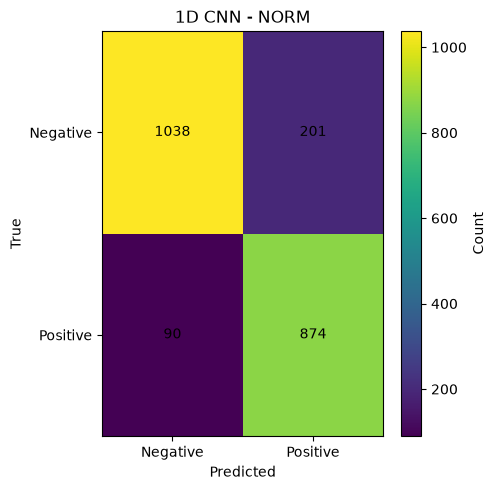

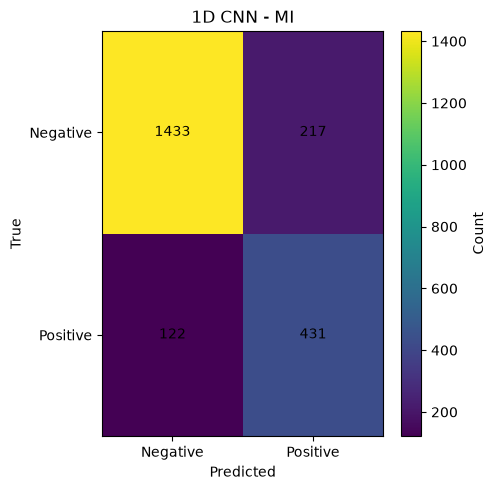

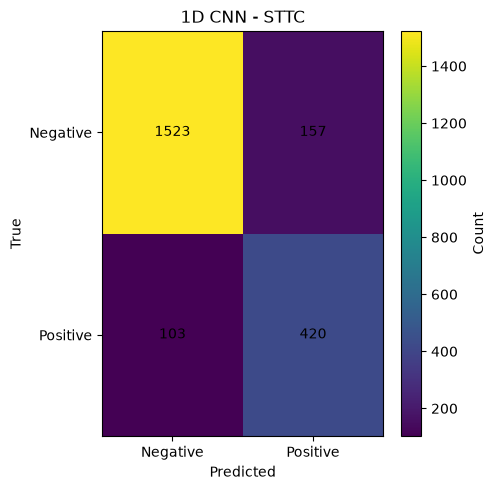

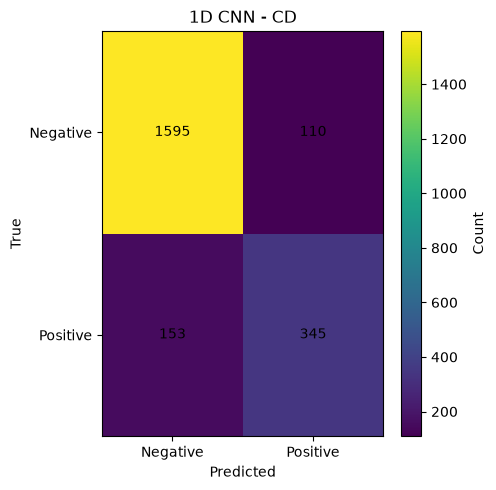

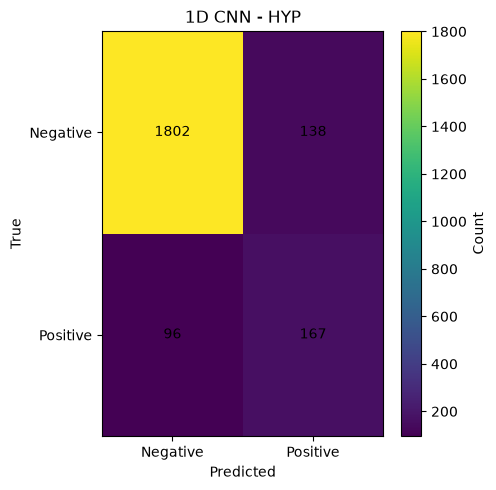

In [23]:

# One binary confusion matrix per PTB-XL diagnostic superclass.

for i, label in enumerate(
    DIAGNOSTIC_COLUMNS
):
    cm = confusion_matrix(
        diagnostic_true[:, i],
        diagnostic_pred[:, i],
        labels=[0, 1],
    )

    plt.figure(figsize=(5, 5))

    plt.imshow(
        cm,
        aspect="auto",
    )

    plt.xticks(
        [0, 1],
        ["Negative", "Positive"],
    )

    plt.yticks(
        [0, 1],
        ["Negative", "Positive"],
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.title(
        f"1D CNN - {label}"
    )

    plt.colorbar(label="Count")

    for row in range(2):
        for col in range(2):
            plt.text(
                col,
                row,
                str(cm[row, col]),
                ha="center",
                va="center",
            )

    plt.tight_layout()
    plt.show()


In [24]:

summary_path = (
    RESULTS_DIR
    / "cnn1d_test_metrics.csv"
)

per_label_path = (
    RESULTS_DIR
    / "cnn1d_test_per_label.csv"
)

threshold_path = (
    RESULTS_DIR
    / "cnn1d_validation_thresholds_used.csv"
)

prediction_rows = []

for i in range(
    len(diagnostic_true)
):
    row = {}

    if "ecg_id" in test_df.columns:
        row["ecg_id"] = test_df.iloc[i]["ecg_id"]

    if "patient_id" in test_df.columns:
        row["patient_id"] = test_df.iloc[i]["patient_id"]

    if "processed_path" in test_df.columns:
        row["record_path"] = test_df.iloc[i][
            "processed_path"
        ]

    for j, label in enumerate(
        DIAGNOSTIC_COLUMNS
    ):
        row[f"{label}_true"] = (
            diagnostic_true[i, j]
        )

        row[f"{label}_prob"] = (
            diagnostic_prob[i, j]
        )

        row[f"{label}_pred"] = (
            diagnostic_pred[i, j]
        )

    prediction_rows.append(row)


predictions_df = pd.DataFrame(
    prediction_rows
)

predictions_path = (
    RESULTS_DIR
    / "cnn1d_test_predictions.csv"
)

summary_df.to_csv(
    summary_path,
    index=False,
)

per_label_df.to_csv(
    per_label_path,
    index=False,
)

threshold_df.to_csv(
    threshold_path,
    index=False,
)

predictions_df.to_csv(
    predictions_path,
    index=False,
)

print("Saved:")
print(summary_path)
print(per_label_path)
print(threshold_path)
print(predictions_path)


Saved:
d:\College Material\Major Project\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\100hz_record_zscore\cnn1d_test_metrics.csv
d:\College Material\Major Project\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\100hz_record_zscore\cnn1d_test_per_label.csv
d:\College Material\Major Project\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\100hz_record_zscore\cnn1d_validation_thresholds_used.csv
d:\College Material\Major Project\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\100hz_record_zscore\cnn1d_test_predictions.csv


In [25]:

print("=" * 70)
print("1D CNN EVALUATION INTEGRITY CHECK")
print("=" * 70)

checks = {
    "Checkpoint exists":
        CHECKPOINT_PATH.exists(),

    "Test set non-empty":
        len(test_dataset) > 0,

    "Five diagnostic classes":
        len(DIAGNOSTIC_COLUMNS) == 5,

    "All test ECGs evaluated":
        len(diagnostic_true)
        == len(test_dataset),

    "Prediction dimension correct":
        diagnostic_prob.shape[1] == 5,

    "Metrics saved":
        summary_path.exists(),
}

for name, passed in checks.items():
    print(
        f"[{'PASS' if passed else 'FAIL'}] "
        f"{name}"
    )

if not all(checks.values()):
    raise RuntimeError(
        "1D CNN evaluation integrity check failed."
    )

print("\nAll integrity checks passed.")


1D CNN EVALUATION INTEGRITY CHECK
[PASS] Checkpoint exists
[PASS] Test set non-empty
[PASS] Five diagnostic classes
[PASS] All test ECGs evaluated
[PASS] Prediction dimension correct
[PASS] Metrics saved

All integrity checks passed.
